In [2]:
import torch
import torchvision
import warnings
import os
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader
from diffusers import DDPMScheduler, UNet2DModel
from matplotlib import pyplot as plt

warnings.filterwarnings("ignore")
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

print("Torch Version:", torch.__version__)
print("CUDA Availablility:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Torch Version: 2.5.1+cu121
CUDA Availablility: True
GPU Name: NVIDIA RTX 2000 Ada Generation Laptop GPU
Using device: cuda


In [3]:
# Data
dataset = torchvision.datasets.MNIST(root="mnist/", train=True, download=True, transform=torchvision.transforms.ToTensor())
print(dataset)

Dataset MNIST
    Number of datapoints: 60000
    Root location: mnist/
    Split: Train
    StandardTransform
Transform: ToTensor()


Input shape: torch.Size([8, 1, 28, 28])
Labels: tensor([6, 5, 7, 2, 6, 3, 5, 6])
Number of batches: 7500


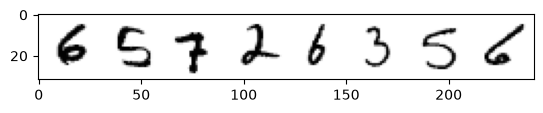

In [4]:
# Dataloader
train_dataloader = DataLoader(dataset=dataset, batch_size=8, shuffle=True)

x, y = next(iter(train_dataloader))
print('Input shape:', x.shape)
print('Labels:', y)
plt.imshow(torchvision.utils.make_grid(x)[0], cmap='Greys')

num_batches = len(train_dataloader)
print(f"Number of batches: {num_batches}")

In [5]:
# Corruption
def corrupt(x, amount):
    """
        Corrupt the input `x` by mixing it with noise according to `amount`
             x: (batch_size, channel, height, width)
         noise: (batch_size, channel, height, width)
        amount: (batch_size)
    """
    noise = torch.rand_like(x)
    amount = amount.view(-1, 1, 1, 1)           # amount: (batch_size) -> (batch_size, 1, 1, 1)
    return x * (1 - amount) + noise * amount    # output: (batch_size, channel, height, width) = (8, 1, 28, 28)

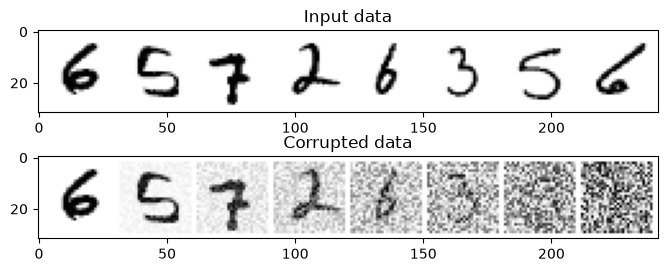

In [6]:
# Plotting the input data
fig, axs = plt.subplots(2, 1, figsize=(8, 3))
axs[0].set_title('Input data')
axs[0].imshow(torchvision.utils.make_grid(x)[0], cmap='Greys')

# Adding noise
amount = torch.linspace(0, 1, x.shape[0]) # Left to right -> more corruption
noised_x = corrupt(x, amount)

# Plotting the noised version
axs[1].set_title('Corrupted data')
axs[1].imshow(torchvision.utils.make_grid(noised_x)[0], cmap='Greys')

In [13]:
# UNet
class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()

        self.down_layers = torch.nn.ModuleList([ 
            nn.Conv2d(in_channels, 32, kernel_size=5, padding=2),
            nn.Conv2d(32, 64, kernel_size=5, padding=2),
            nn.Conv2d(64, 64, kernel_size=5, padding=2),
        ])

        self.up_layers = torch.nn.ModuleList([
            nn.Conv2d(64, 64, kernel_size=5, padding=2),
            nn.Conv2d(64, 32, kernel_size=5, padding=2),
            nn.Conv2d(32, out_channels, kernel_size=5, padding=2), 
        ])

        self.act = nn.SiLU()        # activation function: SiLU(x) = x ⋅ σ(x), where σ(x) is the sigmoid function
        self.downscale = nn.MaxPool2d(2)
        self.upscale = nn.Upsample(scale_factor=2)

    def forward(self, x):
        h = []

        for i, l in enumerate(self.down_layers):
            x = self.act(l(x)) 
            if i < 2: 
                h.append(x) 
                x = self.downscale(x) 
              
        for i, l in enumerate(self.up_layers):
            if i > 0: 
                x = self.upscale(x) 
                x += h.pop() 
            x = self.act(l(x)) 
            
        return x

In [14]:
net = UNet()
x = torch.rand(8, 1, 28, 28)
print("Output shape of UNet:", net(x).shape)

param_num = sum([p.numel() for p in net.parameters()])
print("Number of parameter in UNet:", param_num)

Output shape of UNet: torch.Size([8, 1, 28, 28])
Number of parameter in UNet: 309057


In [15]:
import json
import torch

class TrainingLogger:
    def __init__(self, save_path="mnist_train_loss.jsonl", log_every_n_steps=100):
        self.save_path = save_path
        self.log_every_n_steps = log_every_n_steps

        # Reset/initialize the JSONL file
        with open(self.save_path, "w", encoding="utf-8") as f:
            pass

    def log(self, step, loss, model=None):
        if step % self.log_every_n_steps != 0:
            return

        log_entry = {
            "step": step,
            "loss": loss
        }

        # Append to jsonl
        with open(self.save_path, "a", encoding="utf-8") as f:
            f.write(json.dumps(log_entry) + "\n")
            f.flush()

In [16]:
# Training the network
batch_size = 128
train_dataloader = DataLoader(dataset=dataset, batch_size=batch_size, shuffle=True)

model = UNet().to(device)
n_epochs = 30
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3) 
losses = []
global_step = 0

save_path="mnist_train_loss.jsonl"
log_every_n_steps=100
logger = TrainingLogger(save_path=save_path, log_every_n_steps=log_every_n_steps)

# Training loop
for epoch in range(n_epochs):

    for image, label in train_dataloader:

        image = image.to(device) 
        noise_amount = torch.rand(image.shape[0]).to(device)
        noisy_image = corrupt(image, noise_amount) 

        # Get the model prediction
        pred = model(noisy_image)

        # Calculate the loss
        loss = loss_fn(pred, image)

        # Get current log metrics before optimizer step
        logger.log(
            step=global_step,
            loss=loss.item(),
            model=model
        )

        # Backpropagation and update the parameters
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Store the loss for later
        losses.append(loss.item())

        global_step += 1

    # Print out the average of the loss values for this epoch
    avg_loss = sum(losses[-len(train_dataloader):])/len(train_dataloader)
    print(f'>>> Average loss for epoch {epoch+1}: {avg_loss:05f}')

>>> Average loss for epoch 1: 0.025614
>>> Average loss for epoch 2: 0.019857
>>> Average loss for epoch 3: 0.018517
>>> Average loss for epoch 4: 0.017540
>>> Average loss for epoch 5: 0.016983
>>> Average loss for epoch 6: 0.016585
>>> Average loss for epoch 7: 0.016391
>>> Average loss for epoch 8: 0.016193
>>> Average loss for epoch 9: 0.016063
>>> Average loss for epoch 10: 0.015527
>>> Average loss for epoch 11: 0.015151
>>> Average loss for epoch 12: 0.014828
>>> Average loss for epoch 13: 0.014163
>>> Average loss for epoch 14: 0.014159
>>> Average loss for epoch 15: 0.013770
>>> Average loss for epoch 16: 0.013567
>>> Average loss for epoch 17: 0.013460
>>> Average loss for epoch 18: 0.013268
>>> Average loss for epoch 19: 0.013213
>>> Average loss for epoch 20: 0.013110
>>> Average loss for epoch 21: 0.013035
>>> Average loss for epoch 22: 0.012941
>>> Average loss for epoch 23: 0.012991
>>> Average loss for epoch 24: 0.012768
>>> Average loss for epoch 25: 0.012603
>>> Avera

In [17]:
# Save model weights
print("Saving MNIST model weights ...")
torch.save(model.state_dict(), "mnist_model_weights.pth")
print("MNIST model weights are saved!")

Saving MNIST model weights ...
MNIST model weights are saved!


In [49]:
# Plot
import matplotlib.pyplot as plt
import json
import numpy as np

def load_logs(path="mnist_train_loss.jsonl"):
    logs = []
    with open(path, "r") as f:
        for line in f:
            logs.append(json.loads(line))
            
    return logs

def prepare(logs):
    steps = [x["step"] for x in logs]
    loss = [x["loss"] for x in logs]

    return steps, loss

def plot_training_from_file(path="mnist_train_loss.jsonl"):
    logs = load_logs(path)
    steps, loss = prepare(logs)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

    axes[0].plot(steps, loss, color="red")
    axes[0].set_title("Training Loss")

    axes[1].plot(steps, np.log(loss), color="blue")
    axes[1].set_title("Training Loss in Log Scale")

    for ax in axes:
        ax.set_facecolor("#f5f5f5") 
        ax.grid(True, which="both", linestyle="--", linewidth=0.5, color="darkgray", alpha=0.7)

    fig.suptitle("MNIST Training Summary", fontsize=14)
    plt.tight_layout()
    plt.savefig("mnist_training_summary.png", dpi=300)
    print("Plot successfully saved as 'mnist_training_summary.png'")

Plot successfully saved as 'mnist_training_summary.png'


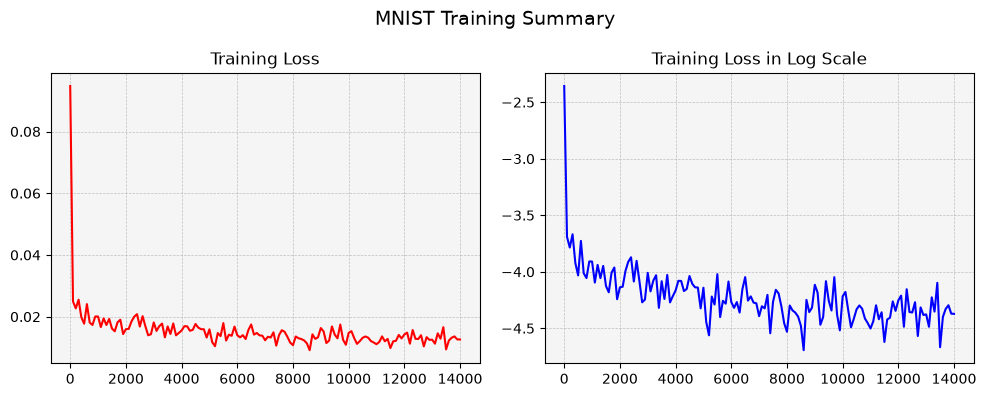

In [50]:
# Plot the loss
plot_training_from_file()

In [24]:
# Load model weights
mnist_model = UNet().to(device)

mnist_model.load_state_dict(torch.load('mnist_model_weights.pth', weights_only=True))
mnist_model.eval()

UNet(
  (down_layers): ModuleList(
    (0): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (2): Conv2d(64, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  )
  (up_layers): ModuleList(
    (0): Conv2d(64, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): Conv2d(64, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (2): Conv2d(32, 1, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  )
  (act): SiLU()
  (downscale): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (upscale): Upsample(scale_factor=2.0, mode='nearest')
)

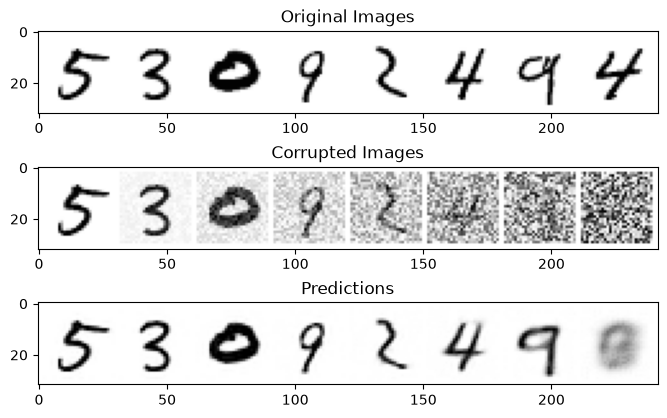

In [25]:
# Fetch some data
image, label = next(iter(train_dataloader))
image = image[:8]

# Corrupt with a range of amounts
amount = torch.linspace(0, 1, image.shape[0])   # Left to right -> more corruption
noisy_image = corrupt(image, amount)

# Get the model predictions
with torch.no_grad():
    preds = mnist_model(noisy_image.to(device)).detach().cpu()

# Plot results
fig, axs = plt.subplots(3, 1, figsize=(8, 5))
axs[0].set_title('Original Images')
axs[0].imshow(torchvision.utils.make_grid(image)[0].clip(0, 1), cmap='Greys')
axs[1].set_title('Corrupted Images')
axs[1].imshow(torchvision.utils.make_grid(noisy_image)[0].clip(0, 1), cmap='Greys')
axs[2].set_title('Predictions')
axs[2].imshow(torchvision.utils.make_grid(preds)[0].clip(0, 1), cmap='Greys')

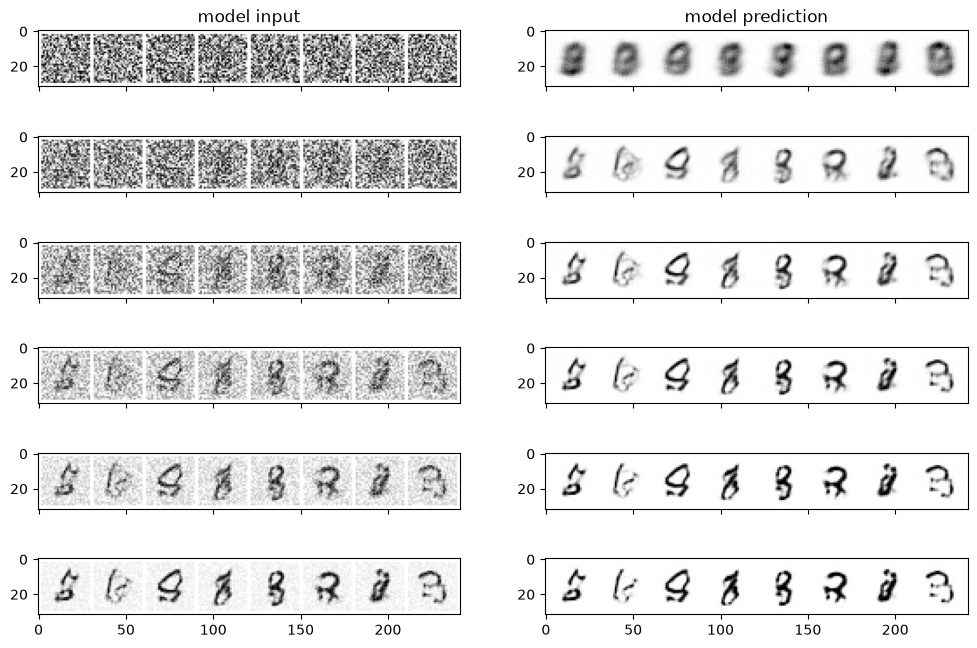

In [ ]:
# Sampling - Strategy: break the process into 6 steps and move 1/6'th of the way there each time:
#
#       e.g.: x = torch.rand(8, 1, 28, 28).to(device)
#
#       for step 0: pred0 = mnist_model(x)
#                   x0 = 5/6 * x + 1/6 * pred0 = 5/6 * x + pred
#       for step 1: pred1 = mnist_model(x0)
#                   x1 = 4/5 * x0 + 1/5 * pred1 = 4/6 * x + 4/30 * pred0 + 1/5 * pred1 = 4/6 * x + pred
#                   ...
#       for step 4: pred4 = mnist_model(x3)
#                   x4 = 1/6 * x + pred
#       for step 5: pred5 = mnist_model(x4)
#                   x5 = 0/6 * x + pred = pred
#
# For this reason, the sampling process moves 1/6'th of the way there each time.

import torch

n_steps = 6
x = torch.rand(8, 1, 28, 28).to(device)
step_history = [x.detach().cpu()]
pred_output_history = []

for i in range(n_steps):
    with torch.no_grad(): 
        pred = mnist_model(x)

    pred_output_history.append(pred.detach().cpu())
    mix_factor = 1 / (n_steps - i)
    x = x * (1 - mix_factor) + pred * mix_factor
    step_history.append(x.detach().cpu())

fig, axs = plt.subplots(n_steps, 2, figsize=(12, 8), sharex=True)
axs[0, 0].set_title('model input')
axs[0, 1].set_title('model prediction')

for i in range(n_steps):
    axs[i, 0].imshow(torchvision.utils.make_grid(step_history[i])[0].clip(0, 1), cmap='Greys')
    axs[i, 1].imshow(torchvision.utils.make_grid(pred_output_history[i])[0].clip(0, 1), cmap='Greys')

In [ ]:
# Create a UNet2DModel
model = UNet2DModel(
    sample_size=28,                     # the target image resolution
    in_channels=1,                      # the number of input channels
    out_channels=1,                     # the number of output channels
    layers_per_block=2,                 # how many ResNet layers to use per UNet block
    block_out_channels=(32, 64, 64),    # roughly matching our basic unet example
    down_block_types=( 
        "DownBlock2D",                  # a regular ResNet downsampling block
        "AttnDownBlock2D",              # a ResNet downsampling block with spatial self-attention
        "AttnDownBlock2D",
    ), 
    up_block_types=(
        "AttnUpBlock2D", 
        "AttnUpBlock2D",                # a ResNet upsampling block with spatial self-attention
        "UpBlock2D",                    # a regular ResNet upsampling block
      ),
)

print(model)
param_num = sum([p.numel() for p in model.parameters()]) 
print("Number of parameter in UNet2DModel:", param_num)    # 1.7M vs ~309k parameters of a basic UNet

UNet2DModel(
  (conv_in): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): Linear(in_features=32, out_features=128, bias=True)
    (act): SiLU()
    (linear_2): Linear(in_features=128, out_features=128, bias=True)
  )
  (down_blocks): ModuleList(
    (0): DownBlock2D(
      (resnets): ModuleList(
        (0-1): 2 x ResnetBlock2D(
          (norm1): GroupNorm(32, 32, eps=1e-05, affine=True)
          (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (time_emb_proj): Linear(in_features=128, out_features=32, bias=True)
          (norm2): GroupNorm(32, 32, eps=1e-05, affine=True)
          (dropout): Dropout(p=0.0, inplace=False)
          (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (nonlinearity): SiLU()
        )
      )
      (downsamplers): ModuleList(
        (0): Downsample2D(
          (conv): Conv2d(32, 32, ker

In [47]:
# Train a UNet2DModel
batch_size = 128
train_dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

n_epochs = 20
model.to(device)
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3) 
losses = []
global_step = 0

save_path="mnist_train_loss_unet2dmodel.jsonl"
log_every_n_steps=100
logger = TrainingLogger(save_path=save_path, log_every_n_steps=log_every_n_steps)

# Training loop
for epoch in range(n_epochs):

    for image, label in train_dataloader:

        image = image.to(device) 
        noise_amount = torch.rand(image.shape[0]).to(device)
        noisy_image = corrupt(image, noise_amount) 

        # Get the model prediction
        pred = model(noisy_image, 0).sample

        # Calculate the loss
        loss = loss_fn(pred, image)

        # Get current log metrics before optimizer step
        logger.log(
            step=global_step,
            loss=loss.item(),
            model=model
        )

        # Backpropagation and update the parameters
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Store the loss for later
        losses.append(loss.item())

        global_step += 1

    # Print out the average of the loss values for this epoch
    avg_loss = sum(losses[-len(train_dataloader):])/len(train_dataloader)
    print(f'>>> Average loss for epoch {epoch+1}: {avg_loss:05f}')

>>> Average loss for epoch 1: 0.018383
>>> Average loss for epoch 2: 0.012609
>>> Average loss for epoch 3: 0.011590
>>> Average loss for epoch 4: 0.011006
>>> Average loss for epoch 5: 0.010788
>>> Average loss for epoch 6: 0.010430
>>> Average loss for epoch 7: 0.010206
>>> Average loss for epoch 8: 0.010109
>>> Average loss for epoch 9: 0.010115
>>> Average loss for epoch 10: 0.009926
>>> Average loss for epoch 11: 0.009774
>>> Average loss for epoch 12: 0.009762
>>> Average loss for epoch 13: 0.009653
>>> Average loss for epoch 14: 0.009539
>>> Average loss for epoch 15: 0.009570
>>> Average loss for epoch 16: 0.009415
>>> Average loss for epoch 17: 0.009432
>>> Average loss for epoch 18: 0.009282
>>> Average loss for epoch 19: 0.009247
>>> Average loss for epoch 20: 0.009175


In [57]:
# Save MNIST UNet2DModel weights
print("Saving MNIST UNet2DModel weights ...")
torch.save(model.state_dict(), "mnist_unet2dmodel_weights.pth")
print("MNIST UNet2DModel weights are saved!")

Saving MNIST UNet2DModel weights ...
MNIST UNet2DModel weights are saved!


In [58]:
# Plot
import matplotlib.pyplot as plt
import json
import numpy as np

def load_logs(path="mnist_train_loss_unet2dmodel.jsonl"):
    logs = []
    with open(path, "r") as f:
        for line in f:
            logs.append(json.loads(line))
            
    return logs

def prepare(logs):
    steps = [x["step"] for x in logs]
    loss = [x["loss"] for x in logs]

    return steps, loss

def plot_training_from_file(path="mnist_train_loss_unet2dmodel.jsonl"):
    logs = load_logs(path)
    steps, loss = prepare(logs)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

    axes[0].plot(steps, loss, color="red")
    axes[0].set_title("Training Loss")

    axes[1].plot(steps, np.log(loss), color="blue")
    axes[1].set_title("Training Loss in Log Scale")

    for ax in axes:
        ax.set_facecolor("#f5f5f5") 
        ax.grid(True, which="both", linestyle="--", linewidth=0.5, color="darkgray", alpha=0.7)

    fig.suptitle("MNIST UNet2DModel Training Summary", fontsize=14)
    plt.tight_layout()
    plt.savefig("mnist_unet2dmodel_training_summary.png", dpi=300)
    print("Plot successfully saved as 'mnist_unet2dmodel_training_summary.png'")

Plot successfully saved as 'mnist_unet2dmodel_training_summary.png'


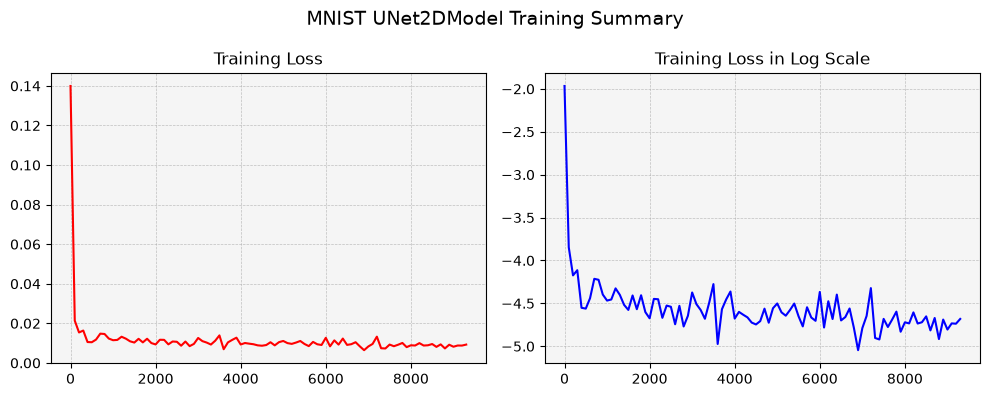

In [59]:
# Plot the loss
plot_training_from_file(path="mnist_train_loss_unet2dmodel.jsonl")

In [62]:
# Load model weights
model = UNet2DModel(
    sample_size=28,                     # the target image resolution
    in_channels=1,                      # the number of input channels
    out_channels=1,                     # the number of output channels
    layers_per_block=2,                 # how many ResNet layers to use per UNet block
    block_out_channels=(32, 64, 64),    # roughly matching our basic unet example
    down_block_types=( 
        "DownBlock2D",                  # a regular ResNet downsampling block
        "AttnDownBlock2D",              # a ResNet downsampling block with spatial self-attention
        "AttnDownBlock2D",
    ), 
    up_block_types=(
        "AttnUpBlock2D", 
        "AttnUpBlock2D",                # a ResNet upsampling block with spatial self-attention
        "UpBlock2D",                    # a regular ResNet upsampling block
      ),
).to(device)

model.load_state_dict(torch.load('mnist_unet2dmodel_weights.pth', weights_only=True))
model.eval()

UNet2DModel(
  (conv_in): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): Linear(in_features=32, out_features=128, bias=True)
    (act): SiLU()
    (linear_2): Linear(in_features=128, out_features=128, bias=True)
  )
  (down_blocks): ModuleList(
    (0): DownBlock2D(
      (resnets): ModuleList(
        (0-1): 2 x ResnetBlock2D(
          (norm1): GroupNorm(32, 32, eps=1e-05, affine=True)
          (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (time_emb_proj): Linear(in_features=128, out_features=32, bias=True)
          (norm2): GroupNorm(32, 32, eps=1e-05, affine=True)
          (dropout): Dropout(p=0.0, inplace=False)
          (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (nonlinearity): SiLU()
        )
      )
      (downsamplers): ModuleList(
        (0): Downsample2D(
          (conv): Conv2d(32, 32, ker

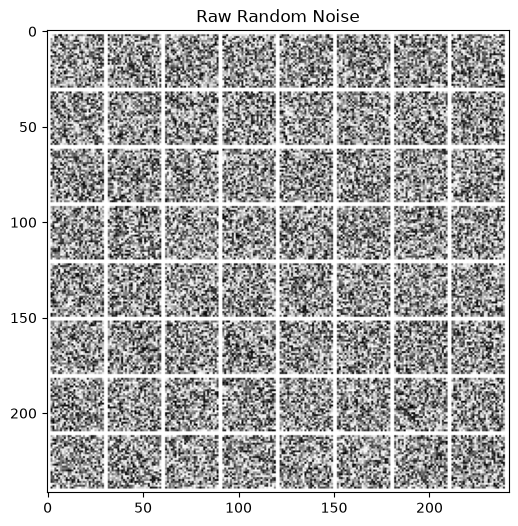

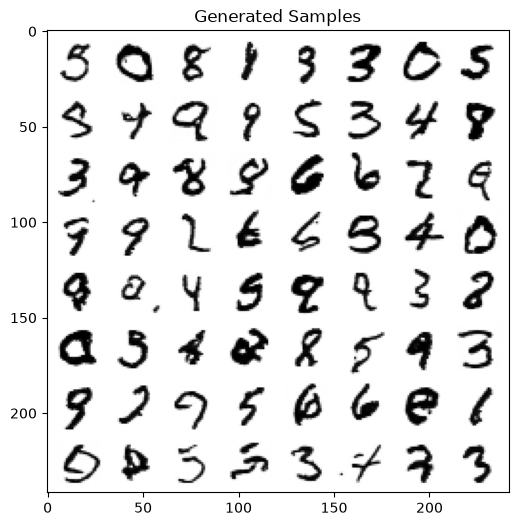

In [64]:
# Samples - using 40 sampling steps
n_steps = 40
x = torch.rand(64, 1, 28, 28).to(device)

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_title('Raw Random Noise')
ax.imshow(torchvision.utils.make_grid(x.detach().cpu(), nrow=8)[0].clip(0, 1), cmap='Greys')
plt.show()

for i in range(n_steps):
    noise_amount = torch.ones((x.shape[0], )).to(device) * (1 - (i / n_steps)) # Starting high going low
    with torch.no_grad():
        pred = model(x, 0).sample
    mix_factor = 1 / (n_steps - i)
    x = x * (1 - mix_factor) + pred * mix_factor

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_title('Generated Samples')
ax.imshow(torchvision.utils.make_grid(x.detach().cpu(), nrow=8)[0].clip(0, 1), cmap='Greys')
plt.show()